In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Detected color: Pink


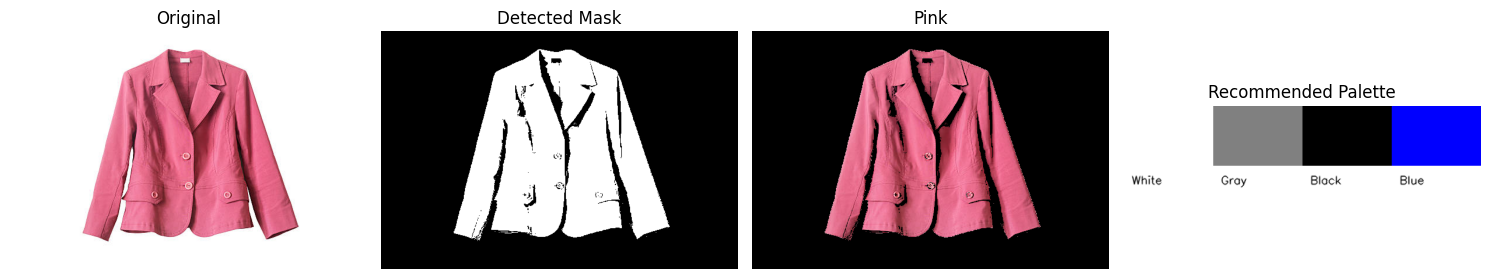

In [14]:

def main():
    #Blue_dress = 'Blue_Dress.jpg' 
    #color_detector(Blue_dress)
    
    #Red_dress = 'Red_dress.jpg'
    #color_detector(Red_dress)
    
    #Yellow_sweater = 'Yellow_sweater.jpg'
    #color_detector(Yellow_sweater)
    
    #Green_shirt = 'Green_tshirt.jpg'
    #color_detector(Green_shirt)
    
    #Black_skirt = 'Black_skirt.jpg'
    #color_detector(Black_skirt)
    
    #Gray_shirt = 'Gray_shirt.jpg'
    #color_detector(Gray_shirt)
    
    Pink_blazer = 'Pink_blazer.jpg'
    color_detector(Pink_blazer)
    
    #Orange_shirt = 'Orange_shirt.jpg'
    #color_detector(Orange_shirt)


def Color_counter(image, lower_color, upper_color):
    
    mask = cv2.inRange(image, lower_color, upper_color)
    num_color = cv2.countNonZero(mask)
    
    return num_color


def draw_palette(recommended_colors, recommended_bgr):
    
    box_width = 120
    palette_height = 120
    palette_width = box_width * len(recommended_colors)
    
    palette = np.ones((palette_height, palette_width, 3), dtype=np.uint8) * 255
    
    for i in range(len(recommended_colors)):
        x1 = i * box_width
        x2 = (i + 1) * box_width
        
        cv2.rectangle(palette, (x1, 0), (x2, 80), recommended_bgr[i], -1)
        
        cv2.putText(
            palette,
            recommended_colors[i],
            (x1 + 10, 105),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 0, 0),
            1,
            cv2.LINE_AA
        )
    
    return palette


def color_detector(image_path):
    # Rojo (dos rangos)
    lower_red1 = np.array([0, 120, 80])
    upper_red1 = np.array([8, 255, 255])

    lower_red2 = np.array([175, 120, 80])
    upper_red2 = np.array([179, 255, 255])

    # Naranja
    lower_orange = np.array([11, 100, 100])
    upper_orange = np.array([20, 255, 255])

    # Amarillo
    lower_yellow = np.array([21, 100, 100])
    upper_yellow = np.array([35, 255, 255])

    # Verde
    lower_green = np.array([36, 80, 80])
    upper_green = np.array([85, 255, 255])

    # Cian
    lower_cyan = np.array([86, 80, 80])
    upper_cyan = np.array([100, 255, 255])

    # Azul
    lower_blue = np.array([101, 100, 80])
    upper_blue = np.array([130, 255, 255])

    # Morado
    lower_purple = np.array([131, 80, 80])
    upper_purple = np.array([160, 255, 255])

    # Rosa
    lower_pink_light = np.array([165, 50, 150])
    upper_pink_light = np.array([179, 160, 255])

    lower_pink_strong = np.array([168, 100, 130])
    upper_pink_strong = np.array([179, 255, 255])

    # Gris
    lower_gray = np.array([0, 0, 50])
    upper_gray = np.array([179, 50, 199])

    # Negro
    lower_black = np.array([0, 0, 0])
    upper_black = np.array([179, 255, 49])
    

    # Read the image
    image = cv2.imread(image_path)
    
    
    # Blur filter
    #image_blur = cv2.GaussianBlur(image, (5, 5), 0)
    
    # Convert the image from BGR to HSV color space
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Count pixels of each color
    Red_count = Color_counter(hsv_image, lower_red1, upper_red1) + Color_counter(hsv_image, lower_red2, upper_red2)
    Orange_count = Color_counter(hsv_image, lower_orange, upper_orange)
    Yellow_count = Color_counter(hsv_image, lower_yellow, upper_yellow)
    Green_count = Color_counter(hsv_image, lower_green, upper_green)
    Cyan_count = Color_counter(hsv_image, lower_cyan, upper_cyan)
    Blue_count = Color_counter(hsv_image, lower_blue, upper_blue)
    Purple_count = Color_counter(hsv_image, lower_purple, upper_purple)
    Pink_count = Color_counter(hsv_image, lower_pink_light, upper_pink_light) + Color_counter(hsv_image, lower_pink_strong, upper_pink_strong)
    Gray_count = Color_counter(hsv_image, lower_gray, upper_gray)
    Black_count = Color_counter(hsv_image, lower_black, upper_black)
    
    Counters = [Red_count, Orange_count, Yellow_count, Green_count, Cyan_count, Blue_count, Purple_count, Pink_count, Gray_count, Black_count]
    Colors = ['Red', 'Orange', 'Yellow', 'Green', 'Cyan', 'Blue', 'Purple', 'Pink', 'Gray', 'Black']
    
    Color_max = max(Counters)
    Color_index = Counters.index(Color_max)
    Detected_color = Colors[Color_index]
    
    print("Detected color:", Detected_color)
    
    # Create mask of detected color
    if Detected_color == 'Red':
        mask1 = cv2.inRange(hsv_image, lower_red1, upper_red1)
        mask2 = cv2.inRange(hsv_image, lower_red2, upper_red2)
        detected_mask = cv2.bitwise_or(mask1, mask2)
        
    elif Detected_color == 'Pink':
        mask1 = cv2.inRange(hsv_image, lower_pink_light, upper_pink_light)
        mask2 = cv2.inRange(hsv_image, lower_pink_strong, upper_pink_strong)
        detected_mask = cv2.bitwise_or(mask1, mask2)
        
    elif Detected_color == 'Orange':
        detected_mask = cv2.inRange(hsv_image, lower_orange, upper_orange)
        
    elif Detected_color == 'Yellow':
        detected_mask = cv2.inRange(hsv_image, lower_yellow, upper_yellow)
        
    elif Detected_color == 'Green':
        detected_mask = cv2.inRange(hsv_image, lower_green, upper_green)
        
    elif Detected_color == 'Cyan':
        detected_mask = cv2.inRange(hsv_image, lower_cyan, upper_cyan)
        
    elif Detected_color == 'Blue':
        detected_mask = cv2.inRange(hsv_image, lower_blue, upper_blue)
        
    elif Detected_color == 'Purple':
        detected_mask = cv2.inRange(hsv_image, lower_purple, upper_purple)
        
    elif Detected_color == 'Gray':
        detected_mask = cv2.inRange(hsv_image, lower_gray, upper_gray)
        
    elif Detected_color == 'Black':
        detected_mask = cv2.inRange(hsv_image, lower_black, upper_black)
    
    detected_region = cv2.bitwise_and(image, image, mask=detected_mask)
    
    # Palettes as lists
    Palettes = [
        ['Black', 'White', 'Gray', 'Blue'],     # Red
        ['White', 'Blue', 'Gray', 'Black'],     # Orange
        ['Purple', 'Blue', 'Gray', 'Black'],    # Yellow
        ['White', 'Gray', 'Black', 'Yellow'],   # Green
        ['White', 'Gray', 'Black', 'Blue'],     # Cyan
        ['White', 'Gray', 'Pink', 'Yellow'],    # Blue
        ['White', 'Gray', 'Yellow', 'Black'],   # Purple
        ['White', 'Gray', 'Black', 'Blue'],     # Pink
        ['Pink', 'Blue', 'Black', 'White'],     # Gray
        ['White', 'Red', 'Pink', 'Gray'],       # Black
    ]
    
    Palette_BGR = [
        [(0, 0, 0), (255, 255, 255), (128, 128, 128), (255, 0, 0)],          # Red
        [(255, 255, 255), (255, 0, 0), (128, 128, 128), (0, 0, 0)],          # Orange
        [(128, 0, 128), (255, 0, 0), (128, 128, 128), (0, 0, 0)],            # Yellow
        [(255, 255, 255), (128, 128, 128), (0, 0, 0), (0, 255, 255)],        # Green
        [(255, 255, 255), (128, 128, 128), (0, 0, 0), (255, 0, 0)],          # Cyan
        [(255, 255, 255), (128, 128, 128), (203, 192, 255), (0, 255, 255)],  # Blue
        [(255, 255, 255), (128, 128, 128), (0, 255, 255), (0, 0, 0)],        # Purple
        [(255, 255, 255), (128, 128, 128), (0, 0, 0), (255, 0, 0)],          # Pink
        [(203, 192, 255), (255, 0, 0), (0, 0, 0), (255, 255, 255)],          # Gray
        [(255, 255, 255), (0, 0, 255), (203, 192, 255), (128, 128, 128)],    # Black
    ]
    
    recommended_colors = Palettes[Color_index]
    recommended_bgr = Palette_BGR[Color_index]
    
    palette_image = draw_palette(recommended_colors, recommended_bgr)
    
    # Convert BGR to RGB for matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    detected_region_rgb = cv2.cvtColor(detected_region, cv2.COLOR_BGR2RGB)
    palette_rgb = cv2.cvtColor(palette_image, cv2.COLOR_BGR2RGB)
    
    # Show results
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 4, 1)
    plt.imshow(image_rgb)
    plt.title('Original')
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(detected_mask, cmap='gray')
    plt.title('Detected Mask')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.imshow(detected_region_rgb)
    plt.title(Detected_color)
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.imshow(palette_rgb)
    plt.title('Recommended Palette')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


main()